In [2]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [3]:
using Revise
using Newtrinos


In [320]:
# STANDARD MODEL

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);


[ Info: Loading Gerda data


In [321]:
par= Newtrinos.get_params(experiments)

(m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [322]:


matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par);

In [323]:
# Effective Majorana mass in SM

mass=Newtrinos.gerda.get_neutrinomass_SM(osc_cfg.flavour)(par)

0.10035849651483787

In [25]:
# NNATURALNESS

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)

[ Info: Loading Gerda data


(N = 100.0, m₀ = 1.0e-6, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [8]:

time_nnm=Newtrinos.gerda.get_halftime(par)

(::Newtrinos.gerda.var"#halftime#6"{@NamedTuple{N::Float64, m₀::Float64, r::Float64, Δm²₂₁::Float64, Δm²₃₁::Float64, δCP::Float64, θ₁₂::Float64, θ₁₃::Float64, θ₂₃::Float64}}) (generic function with 1 method)

In [9]:
# Effective Majorana mass in nnm

mass=Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par)

0.10035982110332639

Mixing angles

In [111]:
par_p= merge(par, (m₀=0.1, r=1e-3, N=100))   

mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.gerda.mixing_angles( par_p, osc_cfg.flavour)

angles_e=angles_e[2:end-1]
angles_m=angles_m[2:end-1]
angles_t=angles_t[2:end-1]

mass_e=mass_e[2:end-1]
mass_m=mass_m[2:end-1]
mass_t=mass_t[2:end-1]


cont_e=mass_e.*(angles_e).^2
cont_m=mass_m.*(angles_m).^2
cont_t=mass_t.*(angles_t).^2






98-element Vector{Float64}:
 1.9271843007069403e-10
 1.6299445509265616e-10
 1.8827560505439678e-10
 2.1752670779174873e-10
 2.4653119643899883e-10
 2.7443627462826455e-10
 3.0105885487162954e-10
 3.264008065051408e-10
 3.505207011334002e-10
 3.7349250739523346e-10
 3.953911549628018e-10
 4.16286969418439e-10
 4.3624431936605663e-10
 ⋮
 5.763978605714892e-10
 5.591265336609819e-10
 5.405517028466602e-10
 5.20491968987953e-10
 4.987117405474891e-10
 4.748958538861233e-10
 4.486054377893045e-10
 4.1919738010061383e-10
 3.856601424834673e-10
 3.462304924963409e-10
 2.972794494779267e-10
 2.2851145868791188e-10

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


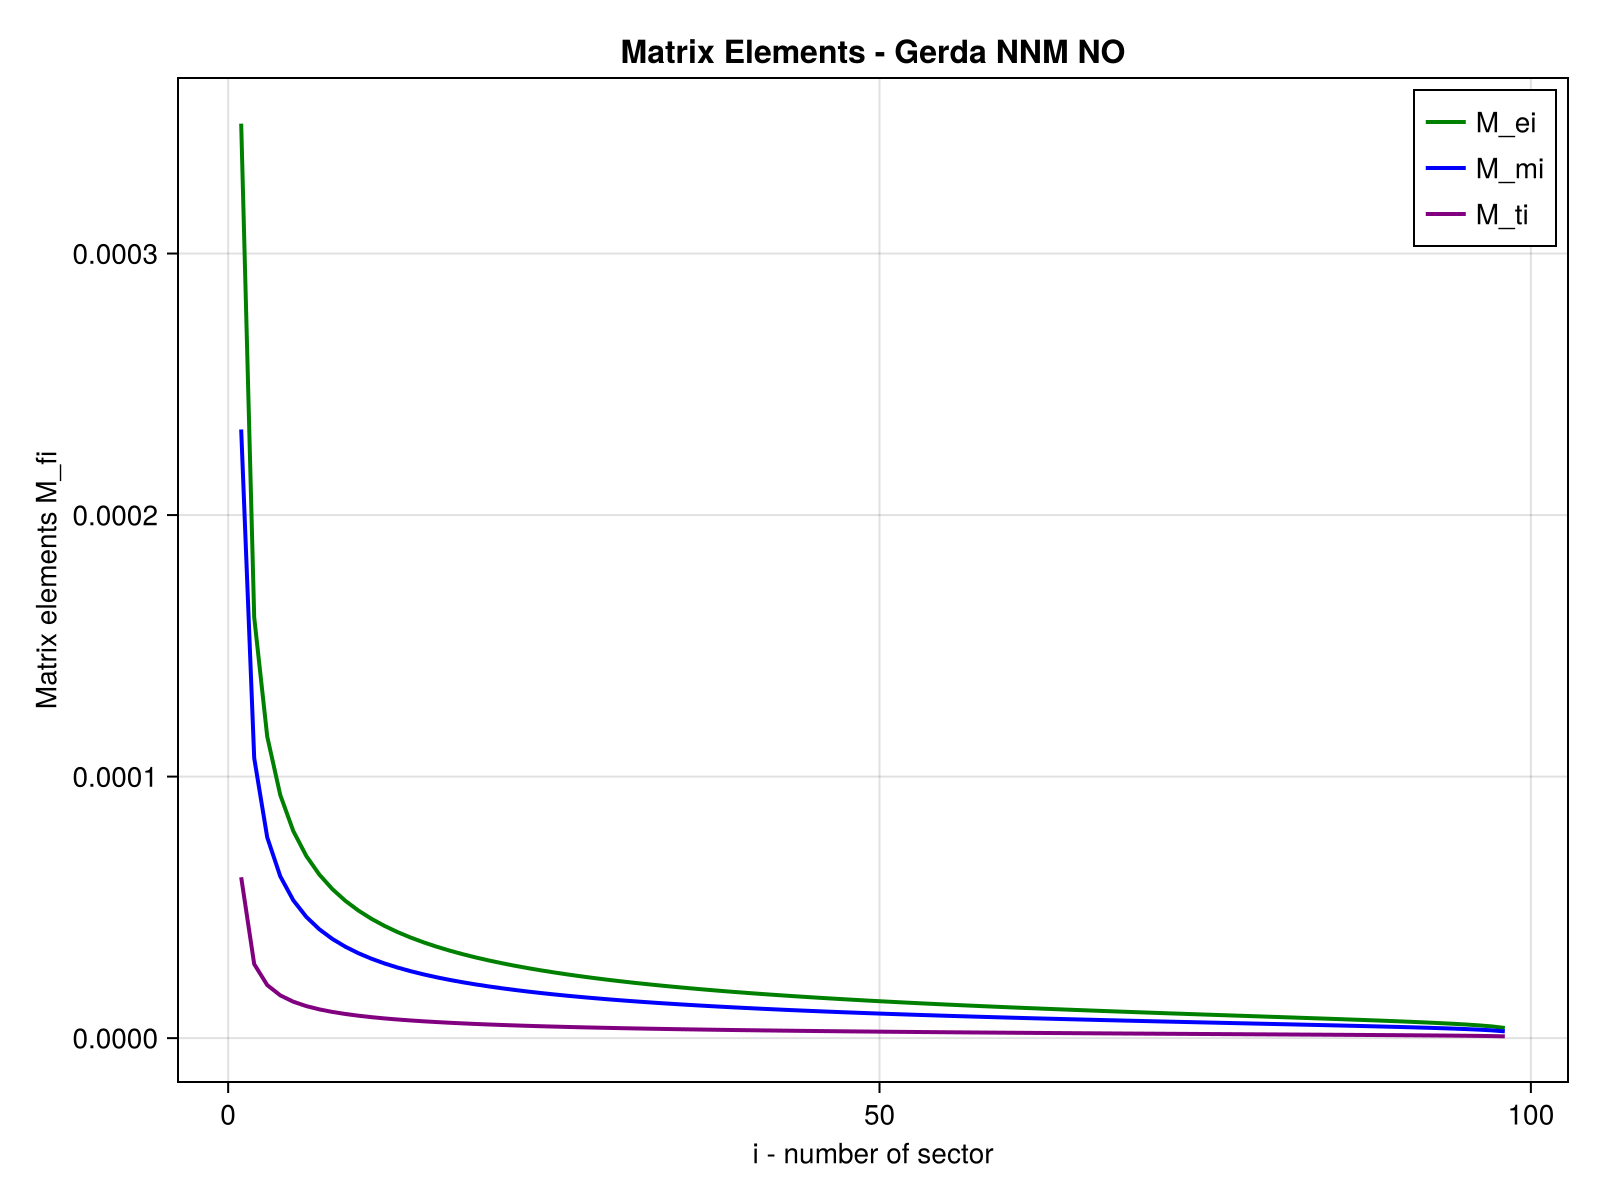

In [112]:
using CairoMakie
# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Matrix elements M_fi",
    title = "Matrix Elements - Gerda NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, abs.(angles_e),
    color = :green,
    linewidth = 2,
    label = "M_ei"
)

lines!(ax, i_range, abs.(angles_m),
    color = :blue,
    linewidth = 2,
    label = "M_mi"
)

lines!(ax, i_range, abs.(angles_t),
    color = :purple,
    linewidth = 2,
    label = "M_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/matrix_elements_N=100_m0=0.1_r=10^-3.png", fig)

display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


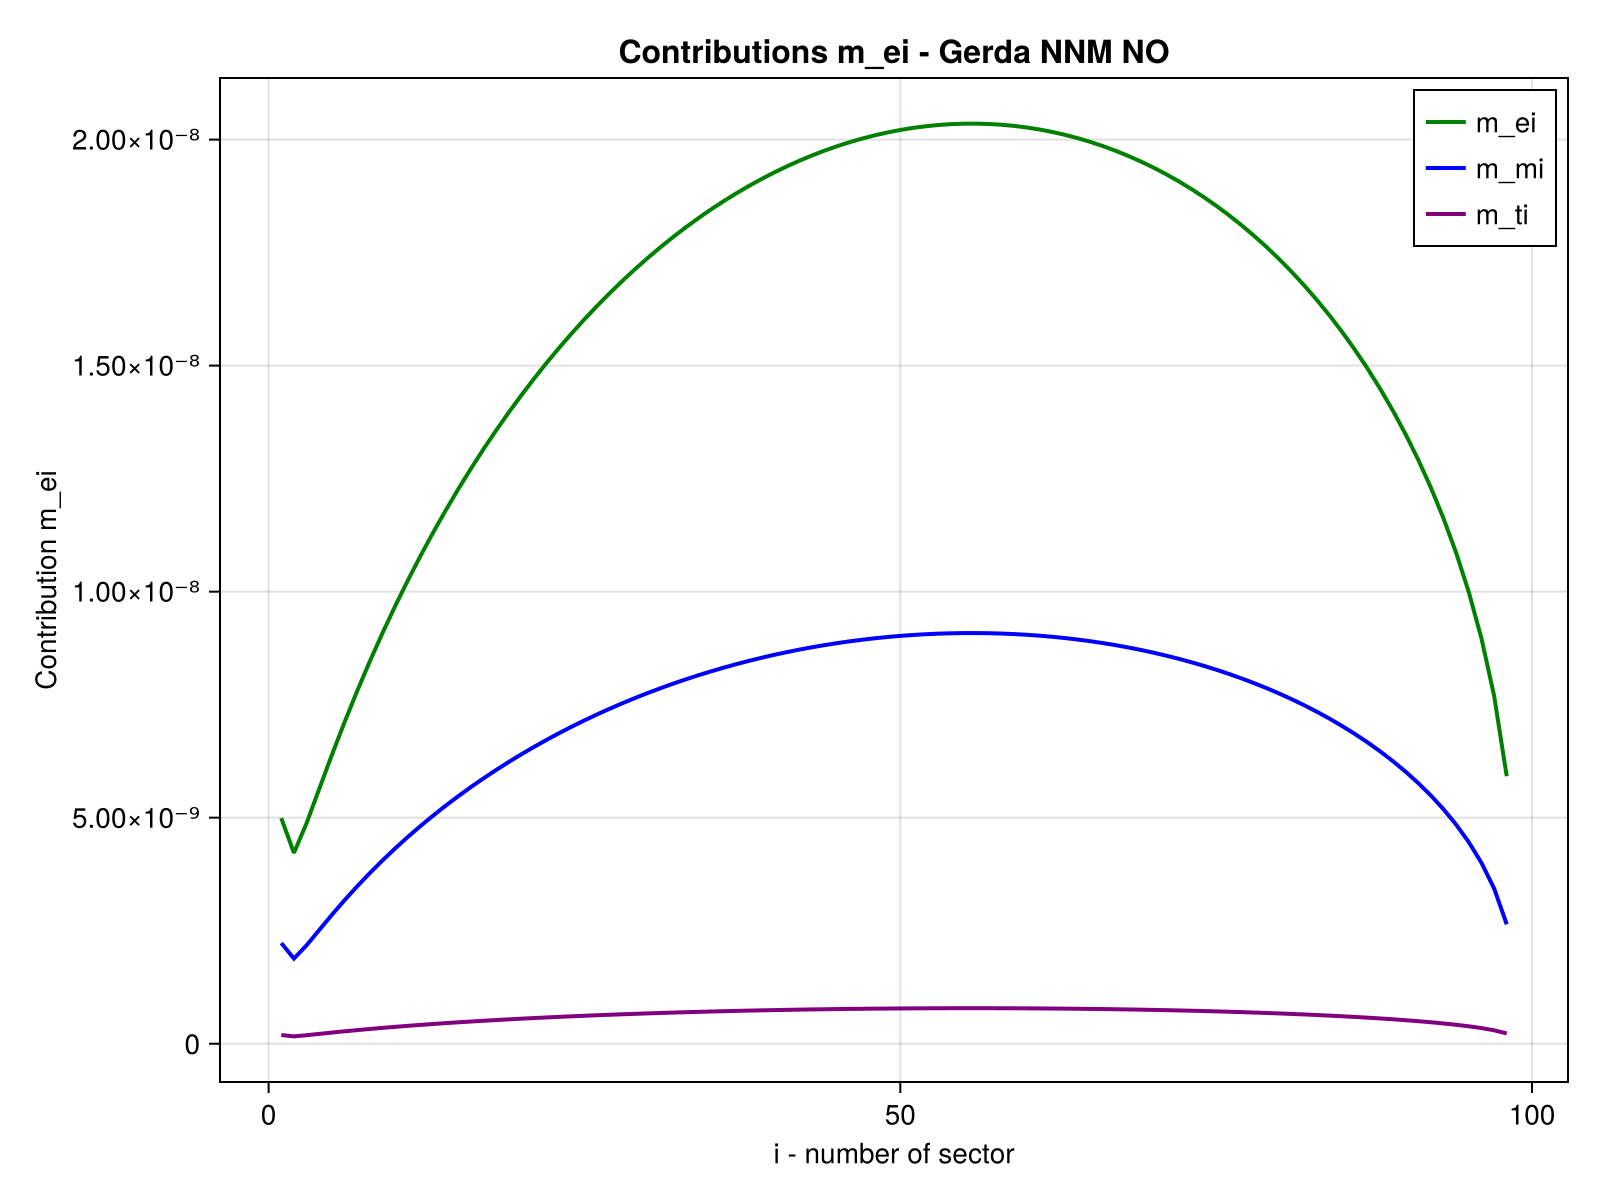

In [113]:

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Contribution m_ei",
    title = "Contributions m_ei - Gerda NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, cont_e,
    color = :green,
    linewidth = 2,
    label = "m_ei"
)

lines!(ax, i_range, cont_m,
    color = :blue,
    linewidth = 2,
    label = "m_mi"
)

lines!(ax, i_range, cont_t,
    color = :purple,
    linewidth = 2,
    label = "m_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/m_contributions_N=100_m0=0.1_r=10^-3.png", fig)


display("image/png", fig)

In [5]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( r=31 ,  m₀ =31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    


(N = Uniform{Float64}(a=1.0, b=200.0), m₀ = Uniform{Float64}(a=1.0e-10, b=0.1), r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [22]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


NewtrinosResult((r = [0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.23333333333333334, 0.26666666666666666, 0.3  …  0.7, 0.7333333333333333, 0.7666666666666667, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], m₀ = [1.0e-6, 0.0033343, 0.0066676, 0.0100009, 0.0133342, 0.016667500000000002, 0.020000800000000003, 0.023334100000000003, 0.0266674, 0.0300007  …  0.0700003, 0.0733336, 0.07666690000000001, 0.08000020000000001, 0.0833335, 0.0866668, 0.09000010000000001, 0.09333340000000001, 0.09666670000000001, 0.1]), (N = [100.0 100.0 … 100.0 100.0; 100.0 100.0 … 100.0 100.0; … ; 100.0 100.0 … 100.0 100.0; 100.0 100.0 … 100.0 100.0], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.00247529

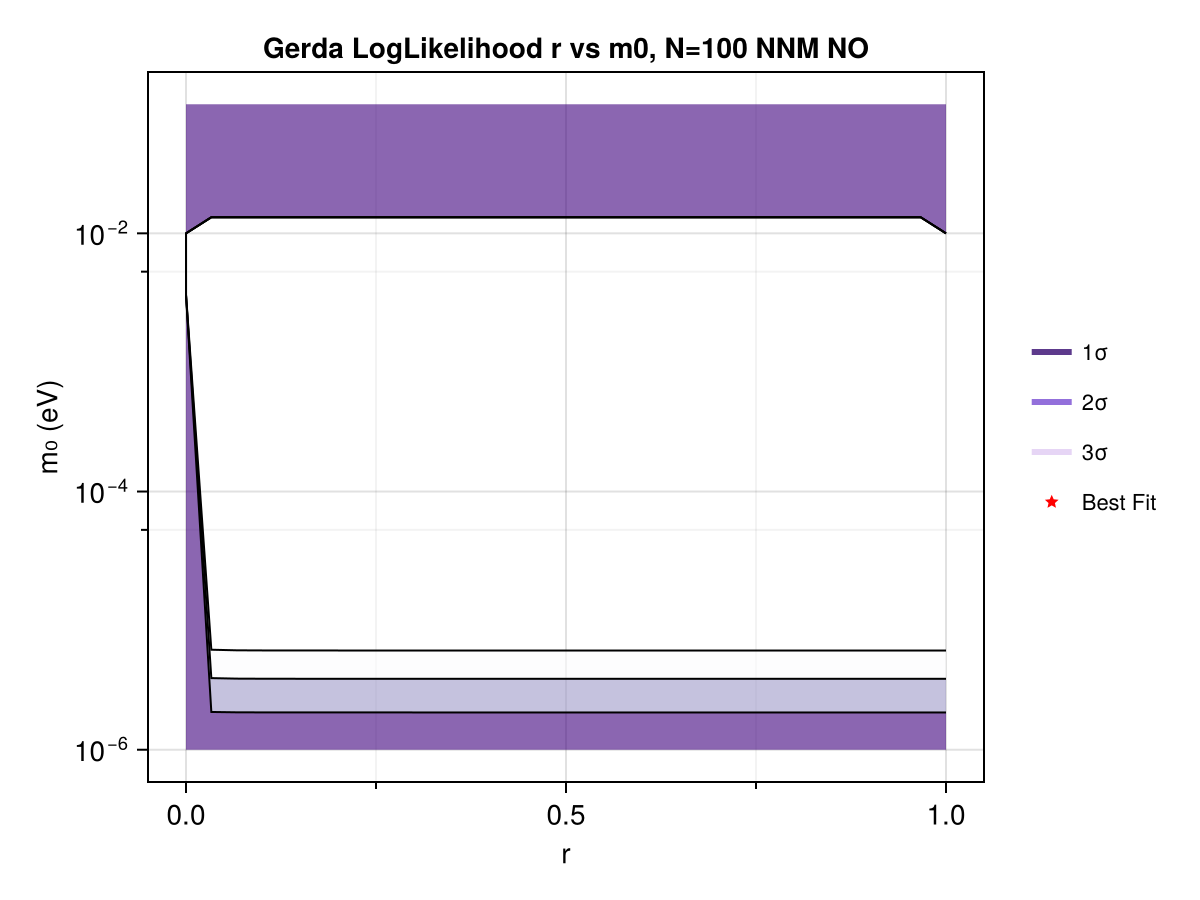

In [24]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="Gerda LogLikelihood r vs m0, N=100 NNM NO")
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/scan_gerda_rm0_N=100_NNM_NO.png", img)

In [26]:

all_priors = Newtrinos.get_priors(experiments)
par= Newtrinos.get_params(experiments)


vars_to_scan = (m₀ =31 ,  N =31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    


(N = Uniform{Float64}(a=1.0, b=100.0), m₀ = Uniform{Float64}(a=1.0e-6, b=1.0), r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [27]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:11


NewtrinosResult((m₀ = [1.0e-6, 0.0333343, 0.0666676, 0.1000009, 0.13333419999999999, 0.1666675, 0.2000008, 0.2333341, 0.26666739999999994, 0.30000069999999995  …  0.7000003, 0.7333335999999999, 0.7666669, 0.8000002, 0.8333335000000001, 0.8666668000000001, 0.9000001, 0.9333334, 0.9666667, 1.0], N = [1.0, 4.3, 7.6, 10.9, 14.2, 17.5, 20.8, 24.1, 27.4, 30.7  …  70.3, 73.6, 76.9, 80.2, 83.5, 86.8, 90.10000000000001, 93.4, 96.7, 100.0]), (r = [1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0; … ; 1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999

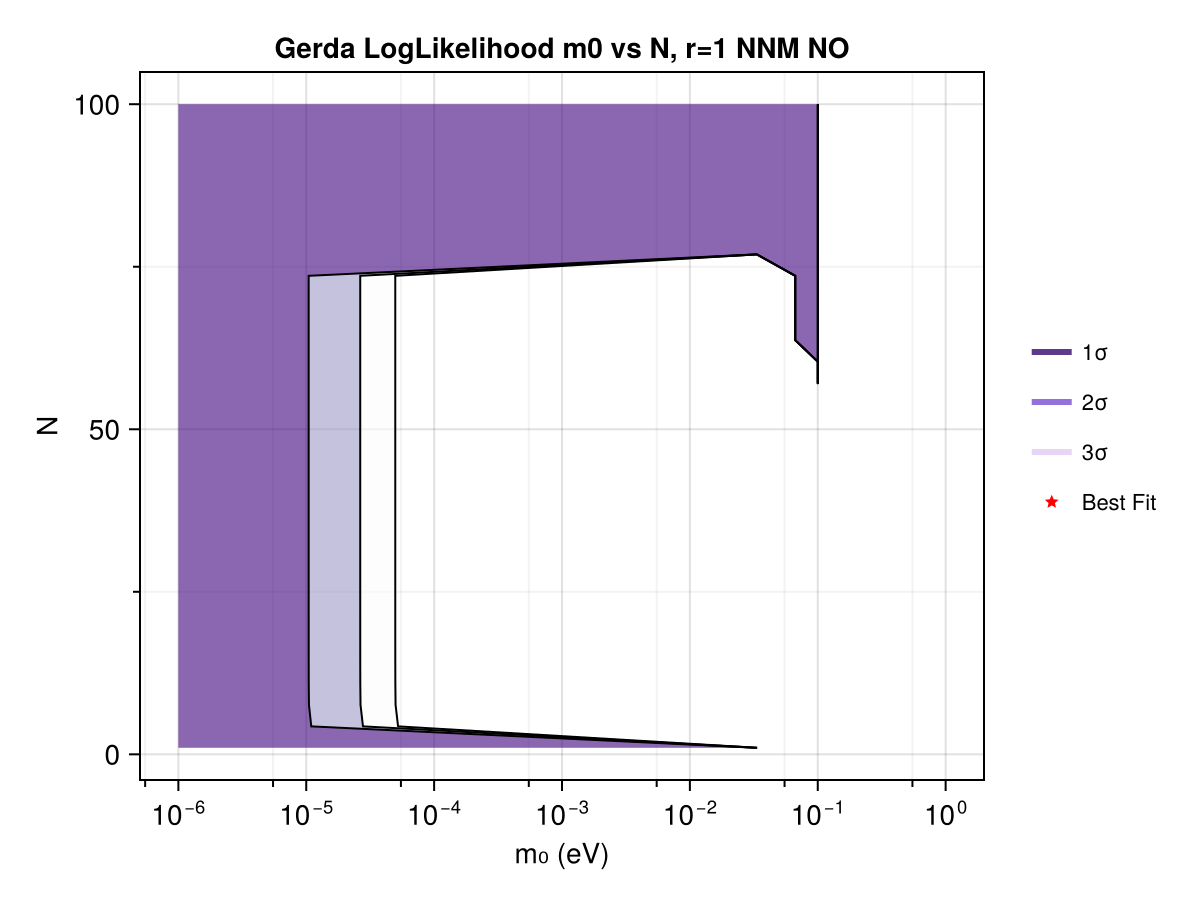

In [28]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="Gerda LogLikelihood m0 vs N, r=1 NNM NO")
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/scan_gerda_m0N_r=1_NNM_NO_1.png", img)

In [350]:
#plot the logposterior value vs r
result = result_NN

#value of r fixed
rfixed =  0#0.00000001
rmax=1
rindex = 1#round(Int, 31/rmax* rfixed)
println("rindex: ", rindex)

#calsculate the best fit
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[rindex ,: ]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[ rindex,: ]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  String(keys(result.axes)[2]),
    ylabel = "Log Posterior",
    title = "m0 vs Log posterior - r = $rfixed - Legend200 NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.m₀, result.values.log_posterior[rindex , :],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
#ave("/home/sofialon/Newtrinos.jl/aug_plots/gerda/legend1000_m0Logpost_NNM_NO_N=100_r=$rfixed.png", fig)


rindex: 1


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


LoadError: type NamedTuple has no field m₀

m0index: 19


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


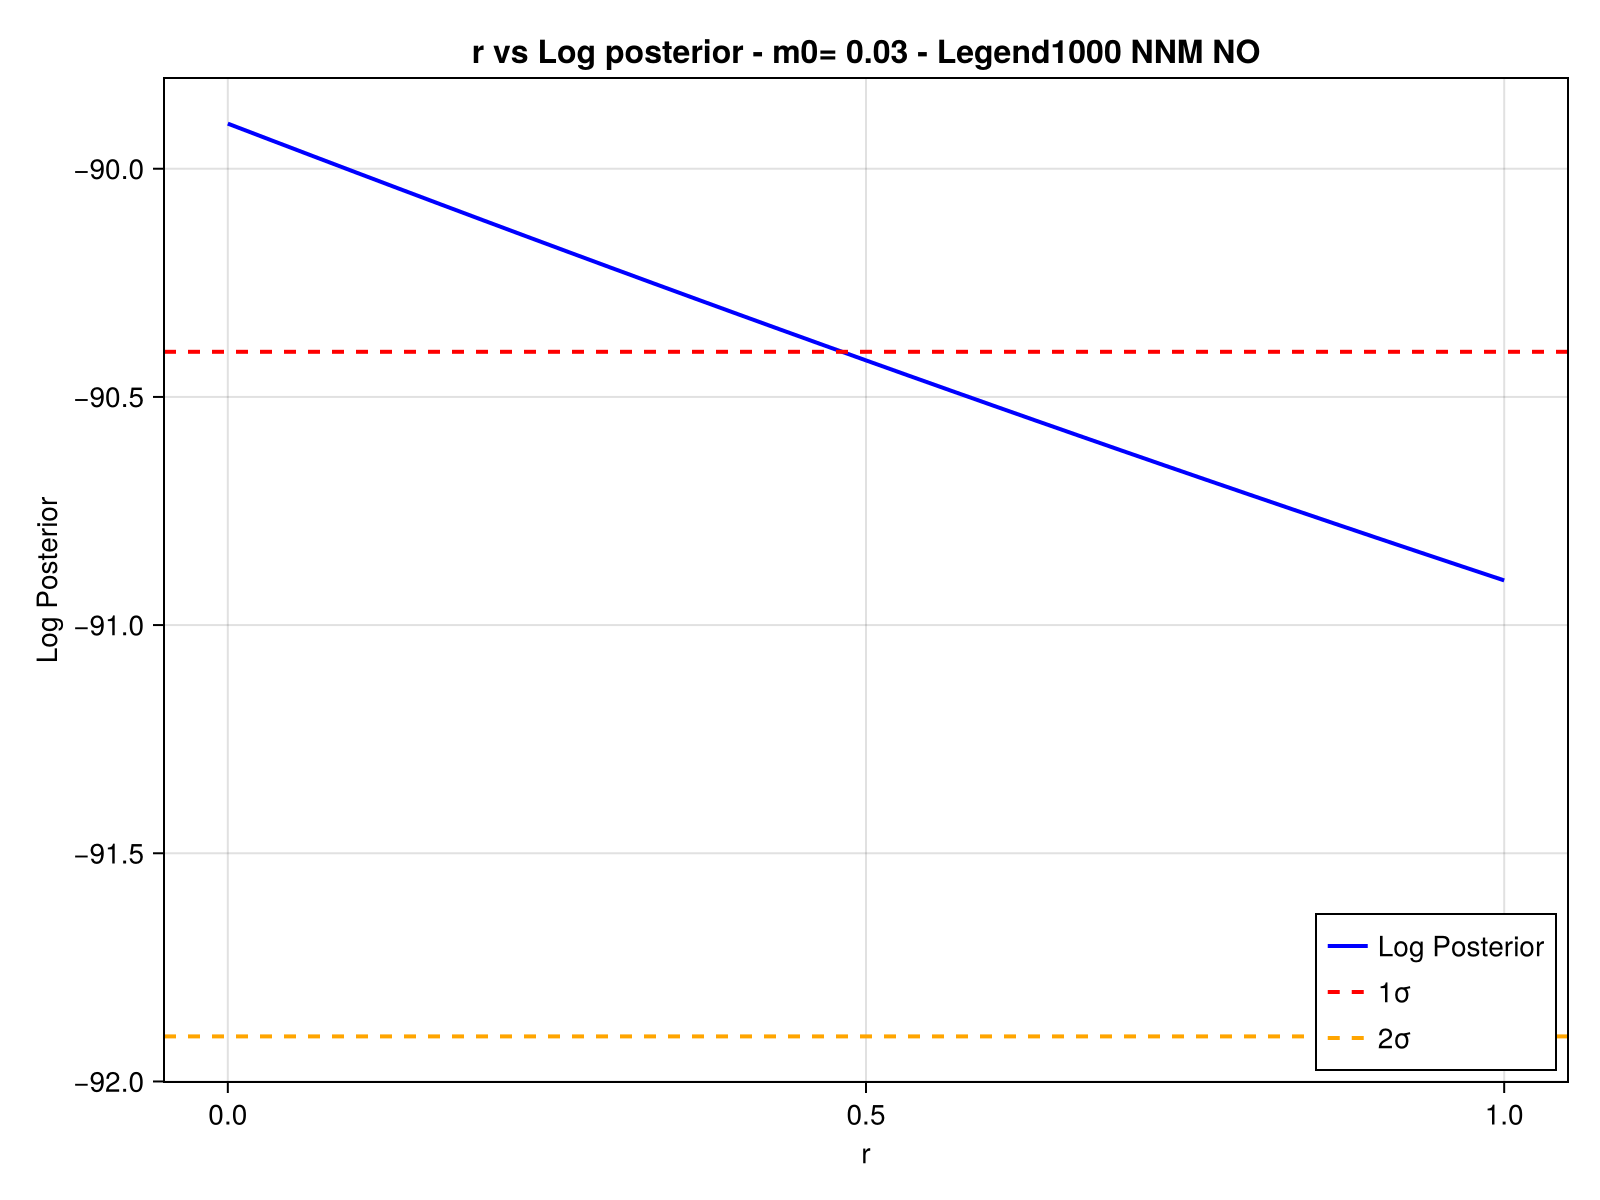

In [ ]:

#value of m0 fixed
m0fixed =0.03
m0max=0.05
m0index = round(Int, 31/m0max* m0fixed)
println("m0index: ", m0index)

#calsculate the best fit
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[:, m0index ]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[:, m0index ]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  String(keys(result.axes)[1]),
    ylabel = "Log Posterior",
    title = "r vs Log posterior - m0= $m0fixed - Legend1000 NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterior[:, m0index],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/legend1000_rLogpost_NNM_NO_N=100_m0=$m0fixed.png", fig)


In [ ]:
#predicted values comparison

using Revise
using Newtrinos


m0_range= LinRange(1e-7, 1e-2, 100)
r_range=LinRange(0, 1.0, 100)

predicted=[]

for m₀ in m0_range
    for r in r_range
        par_new = merge(par, (m₀=m₀, r=r, N=30))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted, pred)
    end
end


Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of masses exceeding threshold: [88, 89, 90]
Indices of m

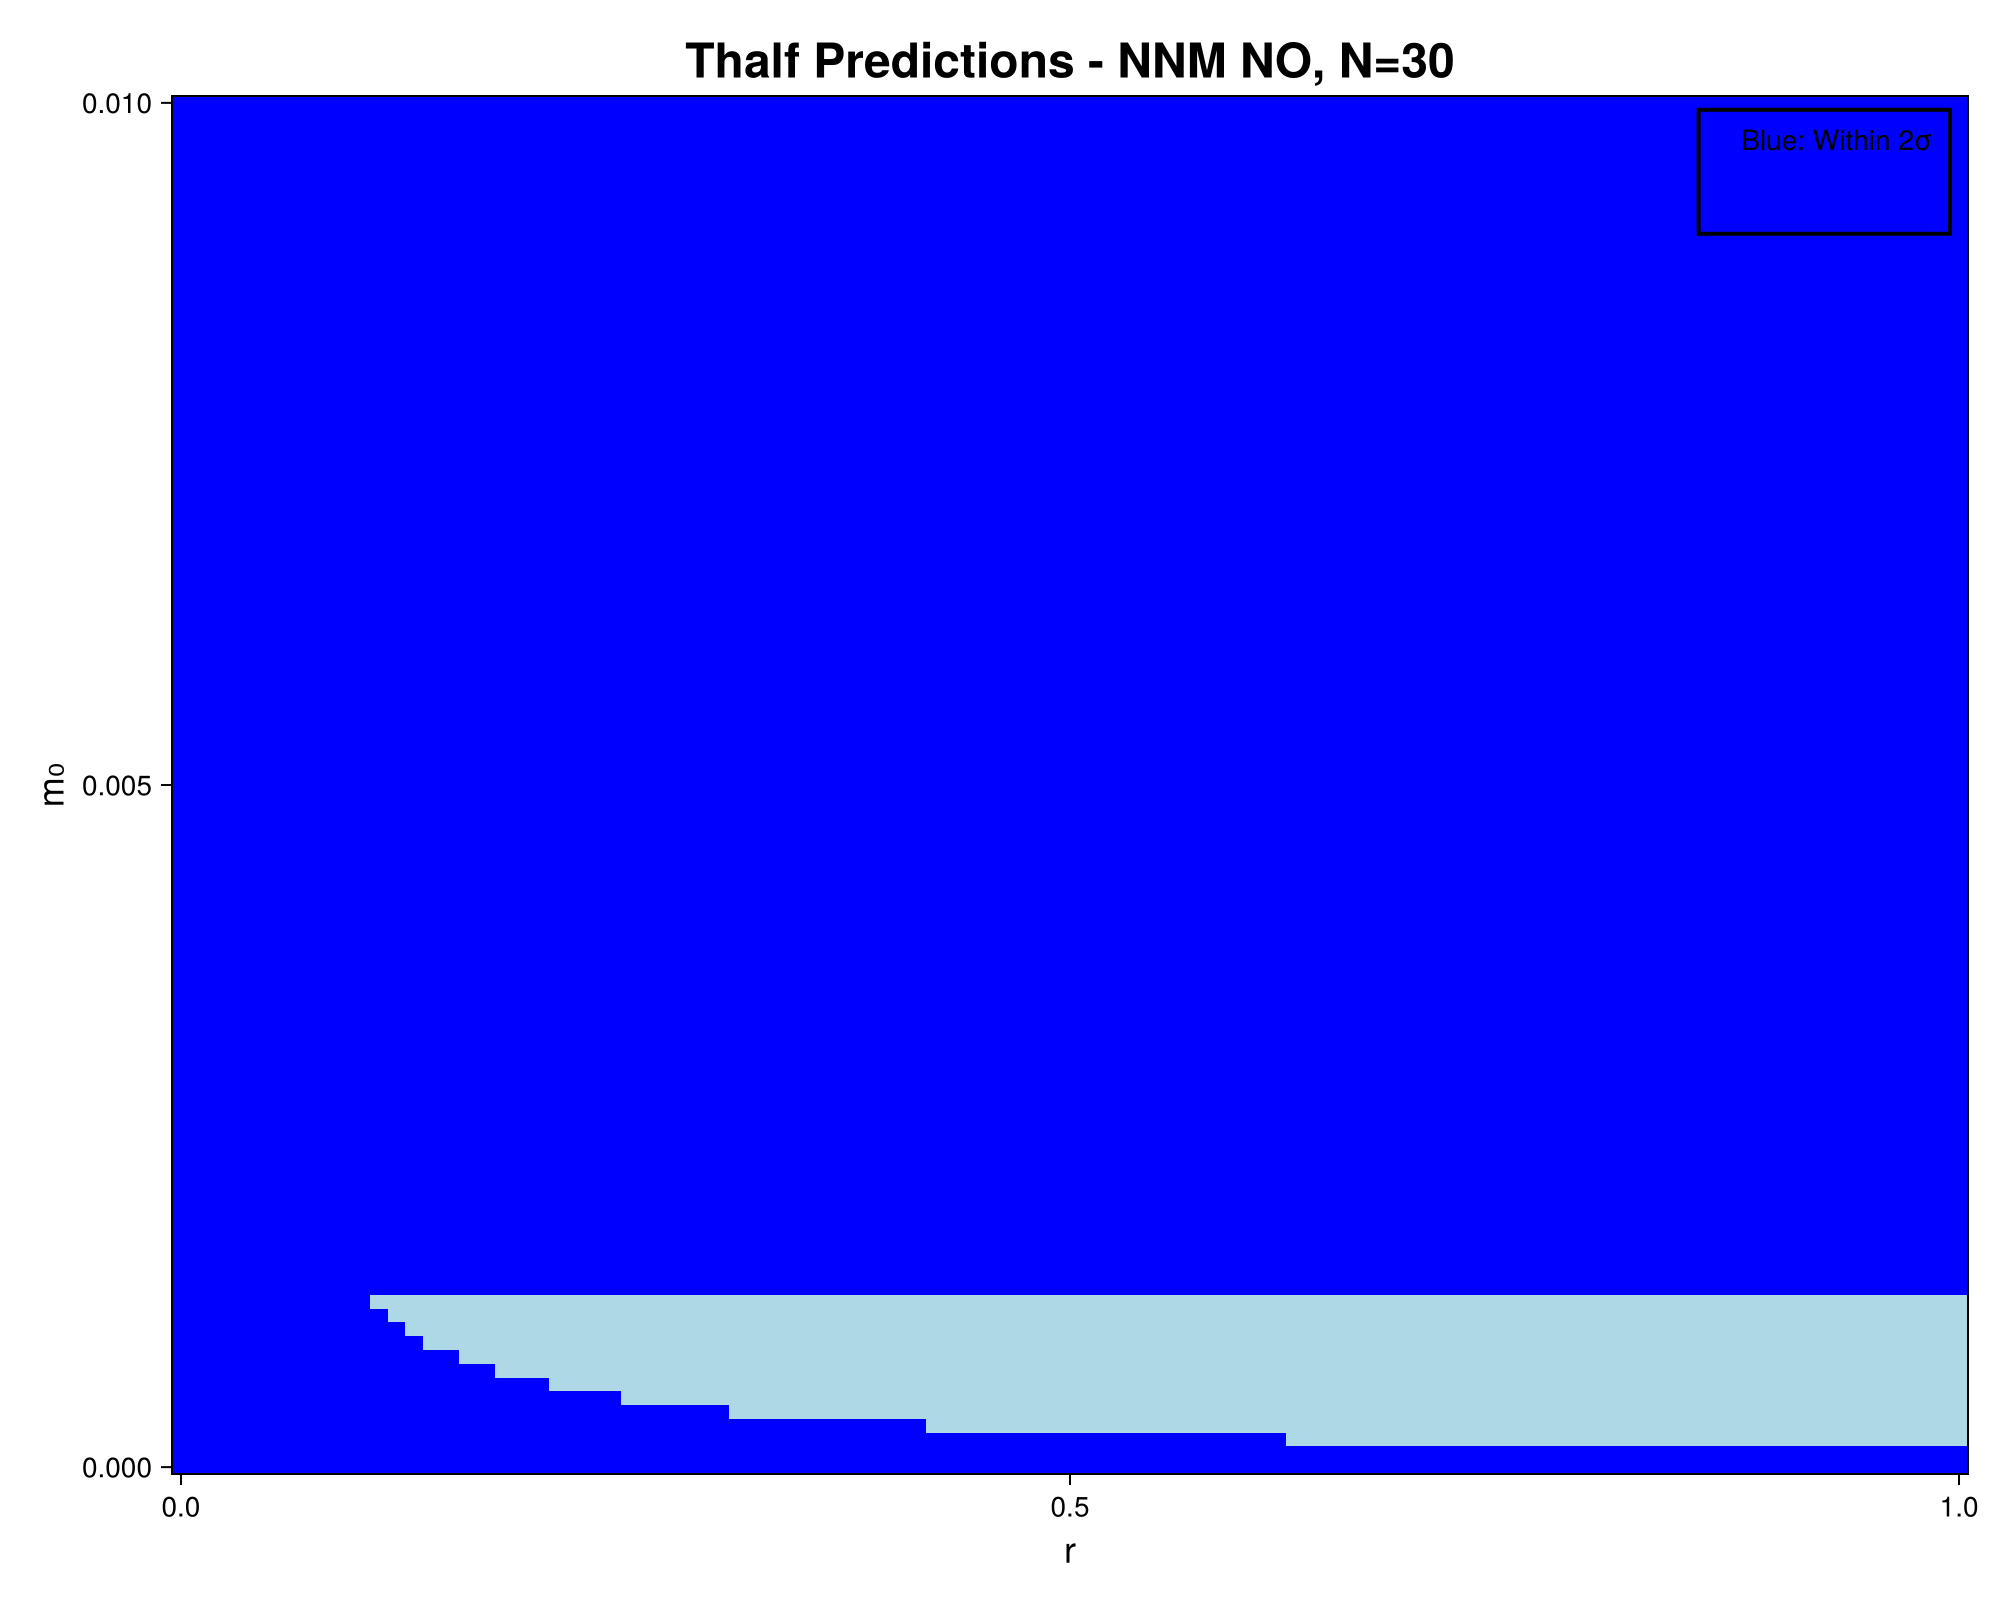

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie

# plotting
observed_dist = Normal(experiments.gerda.assets.observed, 0.1*1e26)
observed_mean = mean(observed_dist)
observed_sigma = std(observed_dist)

# Get the actual lengths
n_r = length(r_range)
n_m0 = length(m0_range)

# Reshape predicted values into 2D array
predicted_2d = reshape(predicted, n_r, n_m0)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2 * observed_sigma
within_2sigma = (predicted_2d .>= lower_bound)

# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig = Figure(size=(1000, 800))
ax = Axis(fig[1, 1],
    ylabel="m₀",
    xlabel="r",
    title="Thalf Predictions - NNM NO, N=30",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax, r_range, m0_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax, 0.98, 0.98,
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax, [0.85, 0.99, 0.99, 0.85, 0.85], [0.90, 0.90, 0.99, 0.99, 0.90],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rm0_N=30.png", fig)
display(fig)

In [ ]:


N_range= LinRange(1, 50, 100)
r_range=LinRange(0, 1.0, 100)

predicted_N=[]

for N in N_range
    for r in r_range
        par_new = merge(par, (N=N, r=r, m₀=0.001))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted_N, pred)
    end
end



In [ ]:
using CairoMakie

# Get the actual lengths
n_r = length(r_range)
n_N = length(N_range)



# Reshape predicted values into 2D array
predicted_2d = reshape(predicted_N, n_r, n_N)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2* observed_sigma

within_2sigma = (predicted_2d .>= lower_bound) #.& (predicted_2d .<= upper_bound)
# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig1 = Figure(size=(1000, 800))
ax1 = Axis(fig1[1, 1],
    ylabel="N", 
    xlabel="r",
    title="Thalf Predictions - NNM NO, m0=0.001",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax1, r_range, N_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax1, 0.98, 0.98, 
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax1, [0.85, 0.99, 0.99, 0.85, 0.85], [0.92, 0.92, 0.99, 0.99, 0.92],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rN_m0=0.001.png", fig1)
display(fig1)